In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.constants
import scipy.stats as stats
import math
import pandas as pd
from matplotlib.colors import ListedColormap
import matplotlib as mpl
import matplotlib.animation as animation
from IPython.display import display, HTML

# Create fading colormaps for multiple 2D histograms
red = plt.cm.Reds  # original colormap
fading_red = red(np.arange(red.N)) # extract colors
fading_red[:, -1] = np.linspace(0, 1, red.N) # modify alpha
fading_red = ListedColormap(fading_red) # convert to colormap

blue = plt.cm.Blues  # original colormap
fading_blue = blue(np.arange(blue.N)) # extract colors
fading_blue[:, -1] = np.linspace(0, 1, blue.N) # modify alpha
fading_blue = ListedColormap(fading_blue) # convert to colormap

mpl.rcParams.update({'font.size': 16, 'axes.labelsize': 16, 'axes.titlesize': 16, 'xtick.labelsize': 16, 'ytick.labelsize': 16, 'legend.fontsize': 16, 'figure.titlesize': 20}) # change font size for all plots

In [3]:
folder = r"C:\Users\newsonj\OneDrive - Lancaster University\Documents\PhD\Electrospray\Testing\2026-09-23 Memristor testing\Force dependent IV\0.7V Area 2\Processed"
file = "FX40_Spectroscopy_Data.pkl"
#file = "TUNA_Ramp_Data_Filtered.pkl"
#file = "TUNA_Ramp_Data_Normalized.pkl"
#file = "TUNA_Ramp_Data_Normalized_Filtered.pkl"

data = pd.read_pickle(folder + "\\" + file)
for idx, row in data.iterrows(): # Ensure all arrays in the row have the same length by padding with NaNs
    max_len = max(len(row["Bias"]), len(row["Current"]), len(row["Log(G/G0)"]))
    for col in ["Bias", "Current", "Log(G/G0)"]:
        arr = row[col]
        if len(arr) < max_len:
            arr = np.append(arr, [np.nan] * (max_len - len(arr)))
            data.at[idx, col] = arr

print(data.head())

def save_plots(folder, title):
    if "Normalized_Filtered" in file:
        plt.savefig(folder + "\\Filtered Normalized "+ title + " .svg", dpi=300, bbox_inches='tight')
        plt.savefig(folder + "\\Filtered Normalized "+ title + " .png", dpi=300, bbox_inches='tight')
    elif "Filtered" in file:
        plt.savefig(folder + "\\Filtered "+ title + " .svg", dpi=300, bbox_inches='tight')
        plt.savefig(folder + "\\Filtered "+ title + " .png", dpi=300, bbox_inches='tight')
    elif "Normalized" in file:
        plt.savefig(folder + "\\Normalized "+ title + " .svg", dpi=300, bbox_inches='tight')
        plt.savefig(folder + "\\Normalized "+ title + " .png", dpi=300, bbox_inches='tight')
    else:
        plt.savefig(folder + "\\" + title + " .svg", dpi=300, bbox_inches='tight')
        plt.savefig(folder + "\\" + title + " .png", dpi=300, bbox_inches='tight')

                         filename  \
0  fP2 IV test_260923_3920__.tiff   
1  fP2 IV test_260923_3921__.tiff   
2  fP2 IV test_260923_3922__.tiff   
3  fP2 IV test_260923_3923__.tiff   
4  fP2 IV test_260923_3924__.tiff   

                                                Bias  \
0  [0.0019198935478925705, 0.007839822210371494, ...   
1  [0.0019198935478925705, 0.007839822210371494, ...   
2  [0.0019198935478925705, 0.007839822210371494, ...   
3  [0.0019198935478925705, 0.007839822210371494, ...   
4  [0.0019198935478925705, 0.007839822210371494, ...   

                                             Current  \
0  [0.027683395892381668, 0.008060429245233536, 0...   
1  [-0.01227034255862236, -0.005704517941921949, ...   
2  [0.03464037552475929, 0.01526886597275734, 0.0...   
3  [0.005648304242640734, 0.017690304666757584, 0...   
4  [0.038673002272844315, 0.029257331043481827, 0...   

                                                dIdV  \
0  [-3.314730255369525e-09, -2.3836822236292683

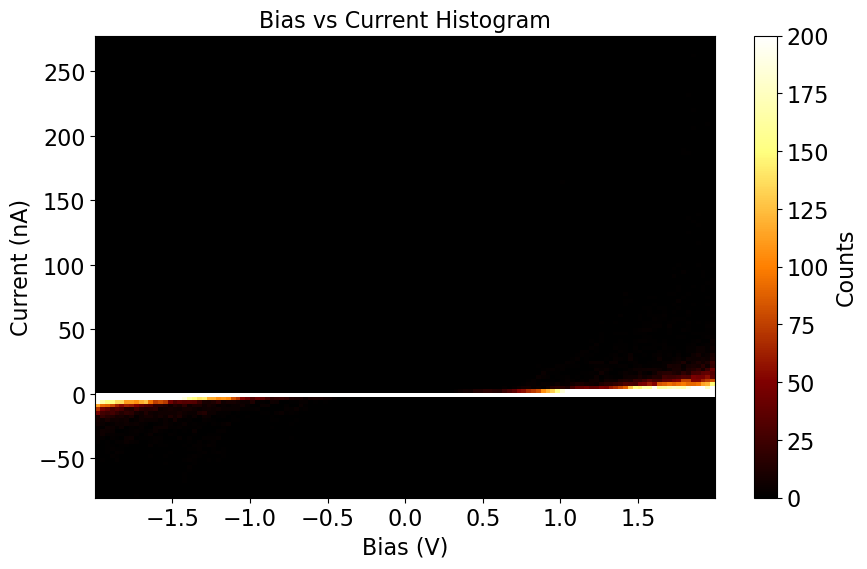

In [4]:
title = "Bias vs Current Histogram"
plt.figure(figsize=(10, 6))
plt.hist2d(np.concatenate(data["Bias"].values),
            np.concatenate(data["Current"].values),
            bins=(128,128), 
            cmap=plt.cm.afmhot, 
            #range=((-0.2,0.2),(-0.03,0.03)), #change range to adjust the x and y axis ranges or comment out for automatic scaling
            vmin = 0, vmax = 200) #change vmin and vmax to adjust the color scale range
plt.colorbar(label='Counts')
plt.xlabel("Bias (V)")
if "Normalized" in file:
    plt.ylabel("Current (nA) per molecule")
else:
    plt.ylabel("Current (nA)")
plt.title(title)

save_plots(folder, title)
    
plt.show()

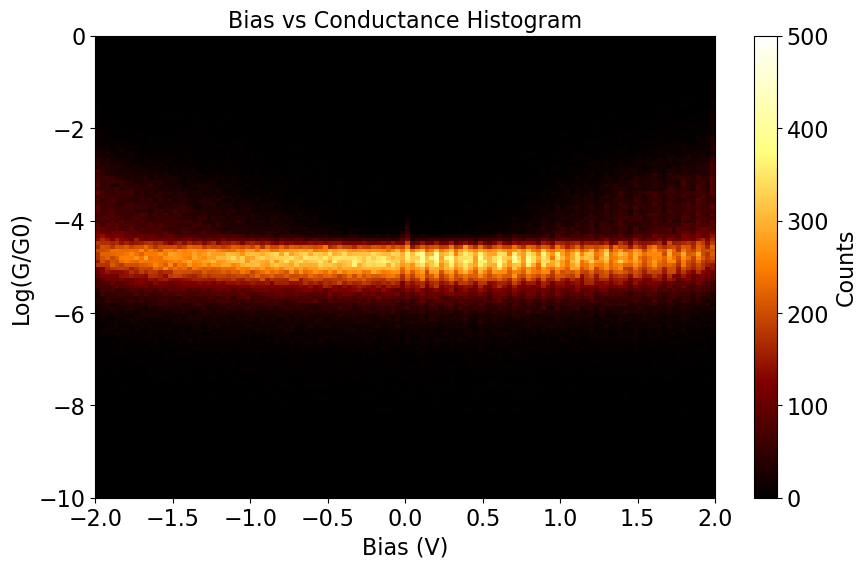

In [10]:
title = "Bias vs Conductance Histogram"
plt.figure(figsize=(10, 6))
plt.hist2d(np.concatenate(data["Bias"].values), 
           np.concatenate(data["Log(G/G0)"].values), 
           bins=(128,128), cmap=plt.cm.afmhot, 
           range=((-2,2),(-10,0)), #change range to adjust the x and y axis ranges or comment out for automatic scaling
           vmin = 0, vmax = 500) #change vmin and vmax to adjust the color scale range
plt.colorbar(label='Counts')
plt.xlabel("Bias (V)")
if "Normalized" in file:
    plt.ylabel("Log(G/G0) per molecule")
else:
    plt.ylabel("Log(G/G0)")
plt.title(title)

save_plots(folder, title)
    
plt.show()